In [9]:
#import useful python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io


In [10]:
#saved SNAD lightcurve
df=pd.read_parquet('snad_lightcurves_grouped_r_band.parquet')

In [11]:
result = df[df['objectId'].isin([
    'ZTF17aaadwas',
    'ZTF17aaaeefu',
    'ZTF25abpedgq'
])]

print(result)

          objectId  finkclass              oid  \
14    ZTF17aaadwas    Unknown  562116300006200   
16    ZTF17aaaeefu  CataclyV*  806113100022828   
2079  ZTF25abpedgq    Unknown  701114400000426   

                                                  mjd_r  \
14    [58216.14385, 58219.13053, 58219.19886, 58350....   
16    [58254.48423, 58256.48011, 58257.46555, 58268....   
2079  [58323.48609, 58329.49247, 58332.41817, 58335....   

                                                  mag_r  \
14    [13.780191, 13.744701, 13.695943, 13.812412, 1...   
16    [17.845242, 16.052643, 15.929454, 17.84879, 17...   
2079  [14.884374, 14.914968, 14.903451, 14.886493, 1...   

                                               magerr_r  \
14    [0.008889622, 0.008864562, 0.008830892, 0.0089...   
16    [0.029613728, 0.016461251, 0.016277904, 0.0296...   
2079  [0.013272989, 0.013297377, 0.013288102, 0.0132...   

                                               filter_r  
14    [zr, zr, zr, zr, zr, zr,

In [12]:
# Export the result to a new file without the index column
result.to_csv('unknown_object.csv', index=False)

In [14]:
df_n=pd.read_csv('unknown_object_modified.csv')

In [15]:
df_n

,objectId,finkclass,oid,mjd_r,mag_r,magerr_r,probablity,Finkclass
0,ZTF17aaadwas,Unknown,5.621160e+14,[58216.14385 58219.13053 58219.19886 ... 60521...,[13.780191 13.744701 13.695943 ... 13.803322 1...,[0.00888962 0.00886456 0.00883089 ... 0.010280...,0.999700,Unknown
1,ZTF17aaaeefu,CataclyV*,8.061130e+14,[58254.48423 58256.48011 58257.46555 ... 59861...,[17.845242 16.052643 15.929454 ... 16.574982 1...,[0.02961373 0.01646125 0.0162779 ... 0.014458...,0.990340,Catacly V*
2,ZTF25abpedgq,Unknown,7.011140e+14,[58323.48609 58329.49247 58332.41817 ... 60503...,[14.884374 14.914968 14.903451 ... 14.915386 1...,[0.01327299 0.01329738 0.0132881 ... 0.014083...,0.992868,Unknown


C:\Users\Mc\AppData\Local\Temp\ipykernel_15736\54153829.py:18: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  mjd = np.fromstring(
C:\Users\Mc\AppData\Local\Temp\ipykernel_15736\54153829.py:23: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  mag = np.fromstring(
C:\Users\Mc\AppData\Local\Temp\ipykernel_15736\54153829.py:28: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  err = np.fromstring(


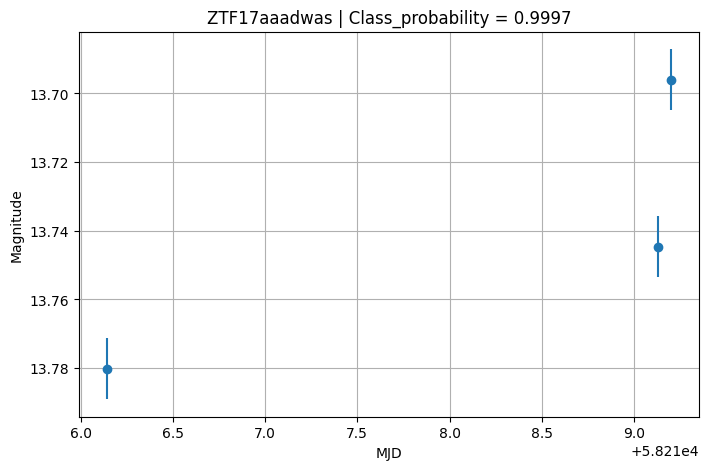

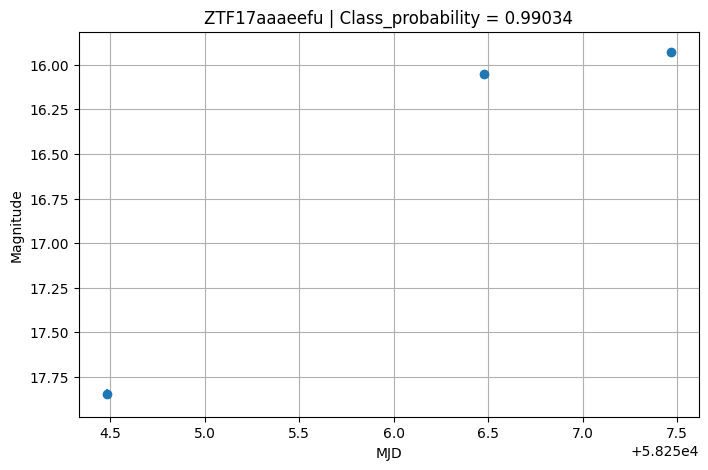

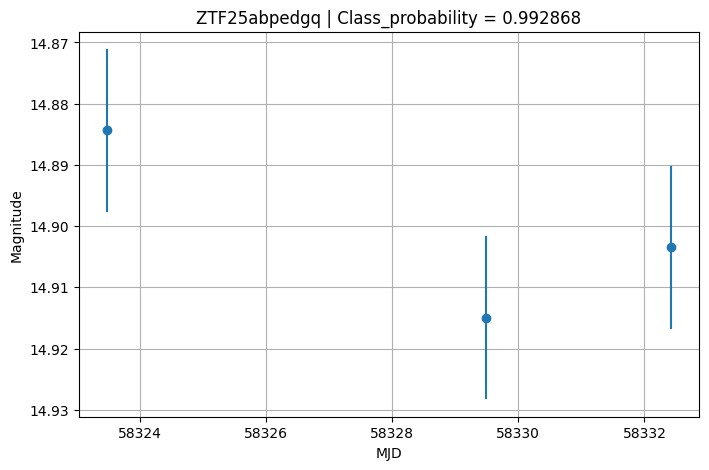

In [20]:
# load file
df = pd.read_csv("unknown_object_modified.csv")

# objects to plot
objects = [
    'ZTF17aaadwas',
    'ZTF17aaaeefu',
    'ZTF25abpedgq'
]

# loop over objects
for obj_id in objects:

    # select row
    obj = df[df['objectId'] == obj_id].iloc[0]

    # convert string arrays to numpy arrays
    mjd = np.fromstring(
        obj['mjd_r'].strip('[]'),
        sep=' '
    )

    mag = np.fromstring(
        obj['mag_r'].strip('[]'),
        sep=' '
    )

    err = np.fromstring(
        obj['magerr_r'].strip('[]'),
        sep=' '
    )

    # create figure
    plt.figure(figsize=(8,5))

    # plot light curve
    plt.errorbar(
        mjd,
        mag,
        yerr=err,
        fmt='o'
    )

    # astronomy convention
    plt.gca().invert_yaxis()

    # labels
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')

   # title
    plt.title(
        f"{obj['objectId']} | Class_probability = {obj['probablity']}"
    )

    plt.grid(True)

    # save figure
    plt.savefig(
        f"{obj_id}_lightcurve.png",
        dpi=300,
        bbox_inches='tight'
    )

    # show plot
    plt.show()